In [59]:
import pandas as pd

# Load the dataset
df = pd.read_csv("sales_data.csv")

# Then preview the first 5 rows
print("First 5 rows:")
display(df.head())

# check basic info about the dataset
print("\nDataset Info:")
df.info()

# summarize key statistics
print("\nSummary Statistics:")
display(df.describe())

First 5 rows:


,OrderID,Date,Product,Category,Quantity,UnitPrice,TotalSales
0,1000,2023-01-01,Headphones,Accessories,1,150,150
1,1001,2023-01-01,Mouse,Accessories,3,50,150
2,1002,2023-01-01,Monitor,Electronics,1,300,300
3,1003,2023-01-01,Mouse,Accessories,2,50,100
4,1004,2023-01-01,Tablet,Electronics,3,500,1500



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 3481 entries, 0 to 3480
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   OrderID     3481 non-null   int64
 1   Date        3481 non-null   str  
 2   Product     3481 non-null   str  
 3   Category    3481 non-null   str  
 4   Quantity    3481 non-null   int64
 5   UnitPrice   3481 non-null   int64
 6   TotalSales  3481 non-null   int64
dtypes: int64(4), str(3)
memory usage: 190.5 KB

Summary Statistics:


,OrderID,Quantity,UnitPrice,TotalSales
count,3481.000000,3481.000000,3481.000000,3481.000000
mean,2740.000000,2.485205,445.101982,1106.004022
std,1005.022471,1.133792,395.928992,1199.332850
min,1000.000000,1.000000,50.000000,50.000000
25%,1870.000000,1.000000,100.000000,200.000000
50%,2740.000000,2.000000,300.000000,600.000000
75%,3610.000000,4.000000,800.000000,1500.000000
max,4480.000000,4.000000,1200.000000,4800.000000


In [60]:

# Sales Performance Summary

# Calculate key business metrics
total_revenue = df["TotalSales"].sum()
total_orders = df["OrderID"].nunique()
total_quantity = df["Quantity"].sum()
average_order_value = total_revenue / total_orders if total_orders else 0

print("SALES PERFORMANCE SUMMARY")
print("-------------------------")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Quantity Sold: {total_quantity}")
print(f"Average Order Value: {average_order_value:,.2f}")

SALES PERFORMANCE SUMMARY
-------------------------
Total Revenue: 3,850,000.00
Total Orders: 3481
Total Quantity Sold: 8651
Average Order Value: 1,106.00


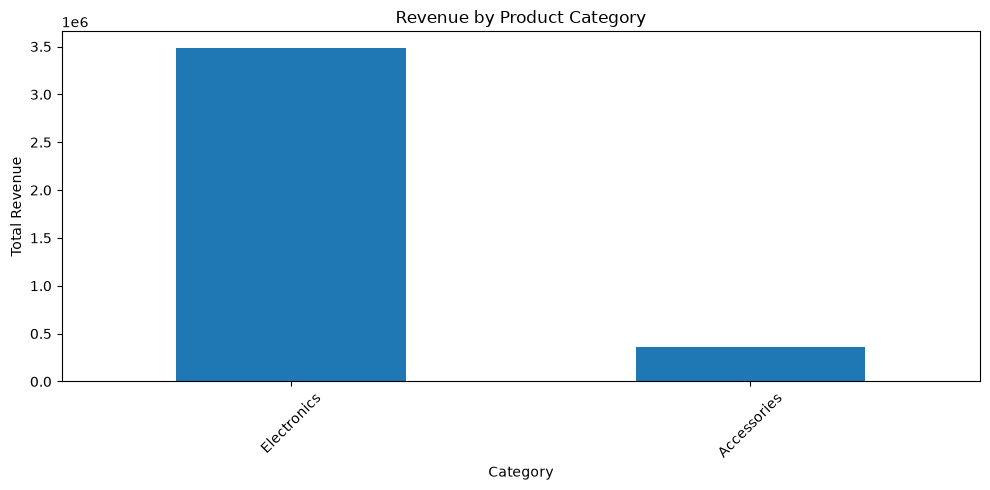

In [61]:

import matplotlib.pyplot as plt

# Calculate revenue by category
category_sales = df.groupby("Category")["TotalSales"].sum().sort_values(ascending=False)

# Create a bar chart
plt.figure(figsize=(10, 5))
category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

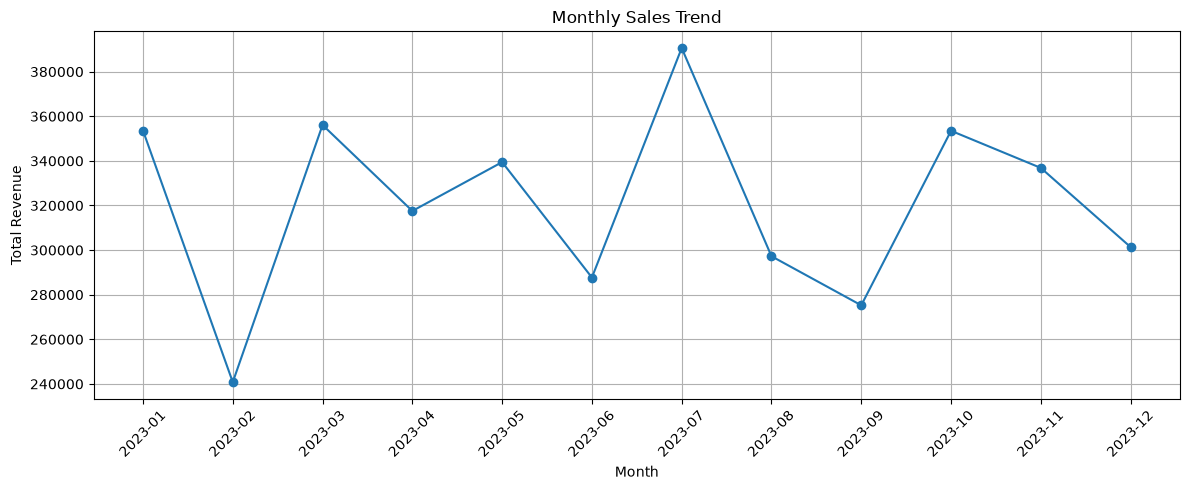

In [62]:

# Monthly Sales Trend Analysis

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract month and year
df["Month"] = df["Date"].dt.to_period("M").astype(str)

# Calculate monthly revenue
monthly_sales = df.groupby("Month")["TotalSales"].sum()

# Plot the monthly sales trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

TOP 10 BEST-SELLING PRODUCTS
Product
Laptop        1518000
Phone          994400
Tablet         610500
Monitor        361800
Headphones     177600
Keyboard       122200
Mouse           65500
Name: TotalSales, dtype: int64


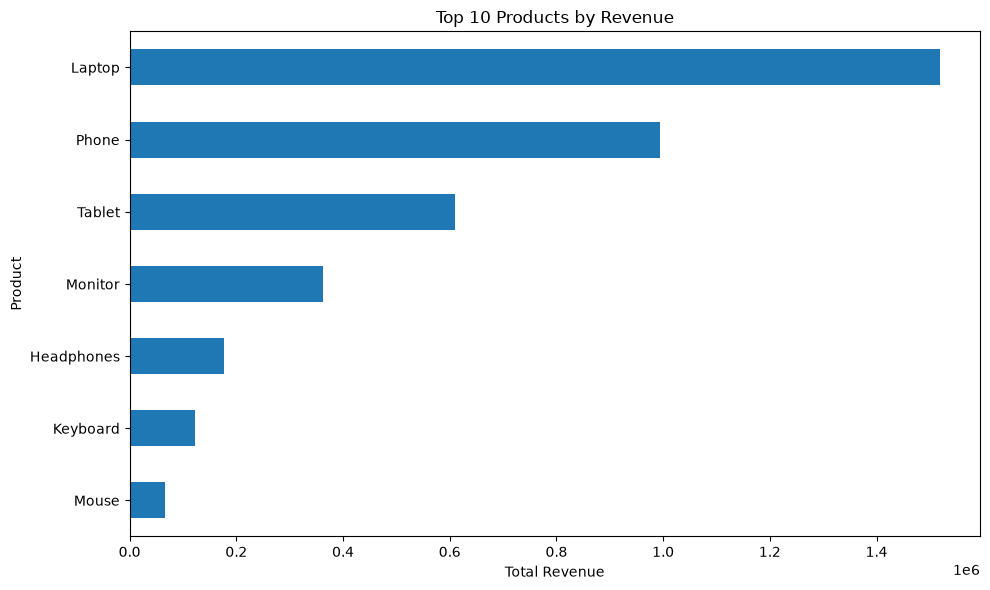

In [63]:

# Top 10 Best-Selling Products

# Calculate total sales by product
product_sales = (
    df.groupby("Product")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
)

# Select the top 10 products
top_products = product_sales.head(10)

# Display the results
print("TOP 10 BEST-SELLING PRODUCTS")
print(top_products)

# Visualize the results
plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [64]:

# Business Insights

# Highest revenue product
best_product = product_sales.idxmax()
best_revenue = product_sales.max()

# Lowest revenue product
lowest_product = product_sales.idxmin()
lowest_revenue = product_sales.min()

# Highest revenue category
best_category = category_sales.idxmax()
category_revenue = category_sales.max()

# Highest sales month
best_month = monthly_sales.idxmax()
month_revenue = monthly_sales.max()

print("BUSINESS INSIGHTS")
print("=" * 30)

print(f"Top Product: {best_product}")
print(f"Revenue: {best_revenue:,.2f}")

print(f"\nLowest Revenue Product: {lowest_product}")
print(f"Revenue: {lowest_revenue:,.2f}")

print(f"\nTop Category: {best_category}")
print(f"Revenue: {category_revenue:,.2f}")

print(f"\nBest Sales Month: {best_month}")
print(f"Revenue: {month_revenue:,.2f}")

BUSINESS INSIGHTS
Top Product: Laptop
Revenue: 1,518,000.00

Lowest Revenue Product: Mouse
Revenue: 65,500.00

Top Category: Electronics
Revenue: 3,484,700.00

Best Sales Month: 2023-07
Revenue: 390,600.00


# Sales Data Analysis Using Python

## Project Overview

This project analyzes sales data using Python to identify revenue trends, product performance and business insights.

## Objectives

* Calculate key sales performance metrics.
* Analyze revenue by product category.
* Visualize monthly sales trends.
* Identify top-performing and low-performing products.
* Generate data-driven business insights.

## Technologies Used

* Python
* Pandas
* Matplotlib
* Jupyter Notebook

## Dataset

The project uses a sample sales dataset containing order IDs, dates, products, categories, quantities, unit prices and total sales.

## Key Features

* Sales performance summary
* Category-wise revenue visualization
* Monthly sales trend analysis
* Top 10 products by revenue
* Automated business insights


# Now we clean the data; check for missing/duplicate values, drop any columns, make any changes necessary

In [65]:
# check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# drop any duplicate rows, if any
df = df.drop_duplicates()

# correct data types
df['Date'] = pd.to_datetime(df['Date'])

# double check the data types
print("\nData types after cleaning:")
print(df.dtypes)

# check table
print(df.sample(20))
display(df.sample(20))

Missing values per column:
OrderID       0
Date          0
Product       0
Category      0
Quantity      0
UnitPrice     0
TotalSales    0
Month         0
dtype: int64

Data types after cleaning:
OrderID                int64
Date          datetime64[us]
Product                  str
Category                 str
Quantity               int64
UnitPrice              int64
TotalSales             int64
Month                    str
dtype: object
      OrderID       Date     Product     Category  Quantity  UnitPrice  \
3335     4335 2023-12-17       Phone  Electronics         2        800   
2765     3765 2023-10-19  Headphones  Accessories         1        150   
1492     2492 2023-06-06  Headphones  Accessories         3        150   
1439     2439 2023-05-31  Headphones  Accessories         2        150   
304      1304 2023-01-31  Headphones  Accessories         4        150   
100      1100 2023-01-10     Monitor  Electronics         2        300   
2940     3940 2023-11-06  Headphones  Ac

,OrderID,Date,Product,Category,Quantity,UnitPrice,TotalSales,Month
2923,3923,2023-11-04,Keyboard,Accessories,2,100,200,2023-11
1292,2292,2023-05-16,Phone,Electronics,2,800,1600,2023-05
640,1640,2023-03-12,Monitor,Electronics,2,300,600,2023-03
1707,2707,2023-06-29,Mouse,Accessories,2,50,100,2023-06
2108,3108,2023-08-08,Tablet,Electronics,2,500,1000,2023-08
212,1212,2023-01-23,Mouse,Accessories,3,50,150,2023-01
2022,3022,2023-07-31,Headphones,Accessories,4,150,600,2023-07
3023,4023,2023-11-14,Laptop,Electronics,2,1200,2400,2023-11
2106,3106,2023-08-08,Tablet,Electronics,1,500,500,2023-08
1942,2942,2023-07-23,Tablet,Electronics,2,500,1000,2023-07


In [66]:
# quick check for calculation errors
df['CheckTotal'] = df['Quantity'] * df['UnitPrice']

# compare with TotalSales
mismatches = df[df['CheckTotal'] != df['TotalSales']]
print("Number of mismatches:", len(mismatches))

# if any mismatches, show the first few
if len(mismatches)> 0:
    display(mismatches.head())

Number of mismatches: 0


# Data set is clean. Now we will move on to analyzing the data/answering some questions that might be useful

In [67]:
# total sales overall
total_sales = df['TotalSales'].sum()
print("Total Sales (all time): $", total_sales)

Total Sales (all time): $ 3850000


### ^^^ The total sales made is $3,850,000

In [68]:
# top products by sales
sales_by_product = df.groupby('Product')['TotalSales'].sum().sort_values(ascending=False)
print("Sales by Product:")
print(sales_by_product)

Sales by Product:
Product
Laptop        1518000
Phone          994400
Tablet         610500
Monitor        361800
Headphones     177600
Keyboard       122200
Mouse           65500
Name: TotalSales, dtype: int64


### ^^^ This shows the total revenue made for each product in ascending order (most to least); Laptops made the most revenue ^^^

In [69]:
# sales by category
sales_by_category = df.groupby('Category')['TotalSales'].sum().sort_values(ascending=False)
print("Sales by Category:")
print(sales_by_category)

Sales by Category:
Category
Electronics    3484700
Accessories     365300
Name: TotalSales, dtype: int64


### ^^^ This shows the sales by category; between electronics & accessories, electronics made the most sales.

In [70]:
# monthly sales trend
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['TotalSales'].sum()
print("Monthly Sales Trend:")
print(monthly_sales)

Monthly Sales Trend:
Date
2023-01    353600
2023-02    240800
2023-03    356100
2023-04    317550
2023-05    339450
2023-06    287700
2023-07    390600
2023-08    297250
2023-09    275250
2023-10    353500
2023-11    336850
2023-12    301350
Freq: M, Name: TotalSales, dtype: int64


### ^^^ This shows the total monthly revenue; We can use this for plotting a visual later.

# Now we will look into the customer behavior over time; The most bought/popular product per month; This is so we can know if more customers buy a product during a certain season or holidays.

In [71]:
# Group by month and product then sum up the quantities
product_monthly = df.groupby([df['Date'].dt.to_period('M'), 'Product'])['Quantity'].sum().reset_index()
print(product_monthly.head(10)) # preview

# Find the top-selling product each month
top_products_per_month = product_monthly.loc[product_monthly.groupby('Date')['Quantity'].idxmax()]
print(top_products_per_month)

      Date     Product  Quantity
0  2023-01  Headphones       116
1  2023-01    Keyboard        96
2  2023-01      Laptop       136
3  2023-01     Monitor       106
4  2023-01       Mouse       126
5  2023-01       Phone        96
6  2023-01      Tablet        97
7  2023-02  Headphones        59
8  2023-02    Keyboard        64
9  2023-02      Laptop        73
       Date     Product  Quantity
2   2023-01      Laptop       136
10  2023-02     Monitor        92
15  2023-03    Keyboard       126
27  2023-04      Tablet       115
28  2023-05  Headphones       139
38  2023-06     Monitor       120
48  2023-07      Tablet       140
53  2023-08       Mouse       112
56  2023-09  Headphones       118
69  2023-10      Tablet       145
74  2023-11       Mouse       147
81  2023-12       Mouse       127


### ^^^ We can preview the data for the quantity of products sold per month; Then we find the top selling product per month. This tells us what's most popular for each month.  

# Now we will plot a chart for the monthly sales trend to visualize how the total sales change over time.

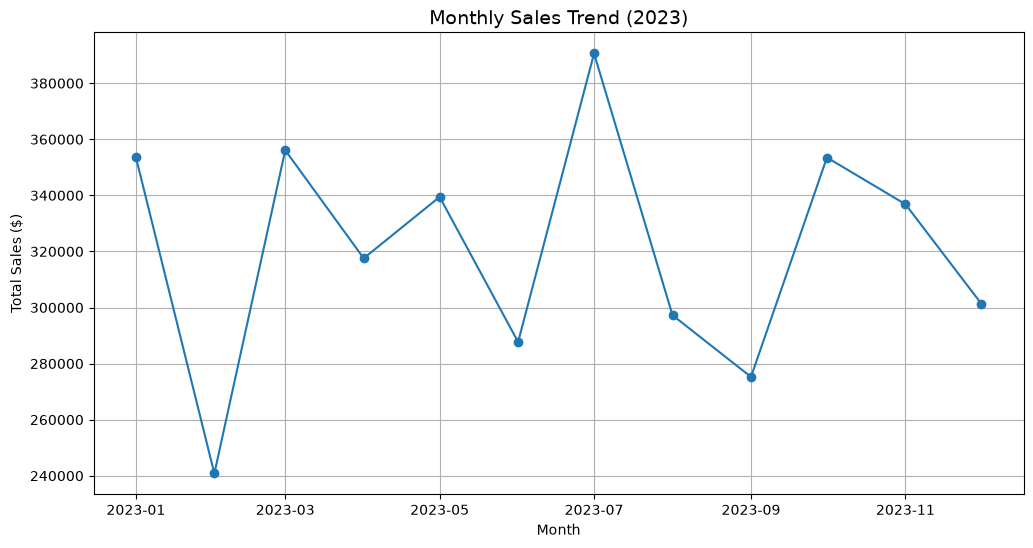

In [72]:
import matplotlib.pyplot as plt

# Group by month and sum total sales
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['TotalSales'].sum()

# Convert Monthly Sales Index to datetime for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

# Plot line chart
plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-')

plt.title("Monthly Sales Trend (2023)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.grid(True)
plt.show()

### ^^^ This shows the monthly sale trend by the total sales; We can see the peak revenue for each month.

# Now for our last step, we can look at customer behavior again & this time we will do the average customer spending value; Wether a customer buys one or a bundle of items.

In [73]:
# Average order value by grouping OrderID & TotalSales
avg_order_value = df.groupby('OrderID')['TotalSales'].sum().mean()
print("Average Order Value (AOV): $", round(avg_order_value, 2))

Average Order Value (AOV): $ 1106.0


### ^^^ This shows how much an average customer spends.

## Now we do the average quantity customers usually buy at once.

In [74]:
# Average quantity by grouping OrderID & Quantity
avg_quantity = df.groupby('OrderID')['Quantity'].sum().mean()
print("Average Quantity per Order:", round(avg_quantity, 2))

Average Quantity per Order: 2.49


# Lastly, we will do a visual chart to show the trend of how many customers buy one or multiple items.

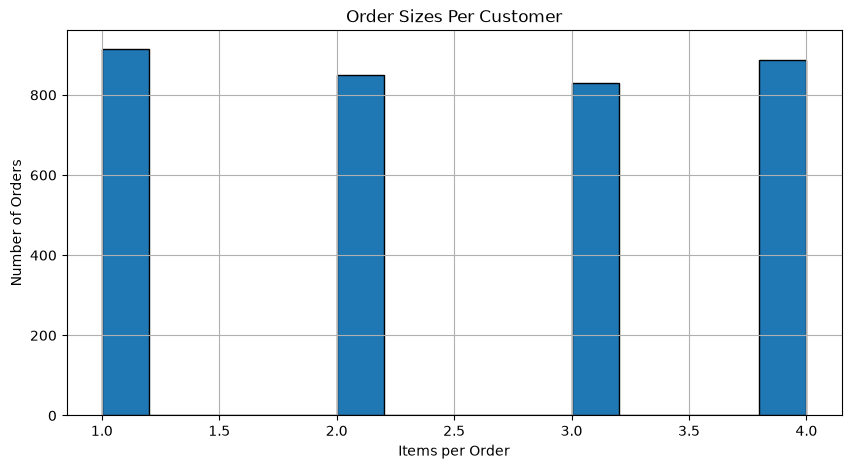

In [75]:
# Create a matplotlib chart by grouping OrderID & Quantity
order_sizes = df.groupby('OrderID')['Quantity'].sum()

plt.figure(figsize=(10,5))
plt.hist(order_sizes, bins=15, edgecolor='black')
plt.title("Order Sizes Per Customer")
plt.xlabel("Items per Order")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.show()

### ^^^ The chart shows how many items a customer has per order; Ex. almost 900 customers buy 4 items. 

# 🧾 Beginner Friendly Sales Data Analysis Project (Python)

## Summary of Steps
1. Loaded & explored the dataset (info & statistics)
2. Cleaned the data (checked types, duplicates, and totals)
3. Analyzed total revenue overall, by product, & by category
4. Visualized monthly sales trend
5. Explored customer/order insights:
    - Average order value
    - Average item size per order
    - Distribution of order sizes

## Key Insights
- **Top Product:** Laptops generated the most revenue.
- **Top Category:** Electronics drove the majority of sales.
- **Monthly Trend:** Sales peaked in November, October, & July, possibly due to the season or holiday.
- **Customer Behavior:** On average, customers spent ~$1,106 per order & bought ~2.5 items.